<a href="https://colab.research.google.com/github/matti410/Trading-System-Pipeline-ML/blob/main/TS-Pipeline-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q TA-Lib==0.8.1 backtesting==0.6.6   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 4.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Pipeline-ML')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Pipeline-ML.git

%cd Trading-System-Pipeline-ML

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Pipeline-ML'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 24 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 182.78 KiB | 11.42 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/Trading-System-Pipeline-ML


In [3]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import sys
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime as dt
"""
from mt5_interaction import start_mt5, set_query_timeframe, retrieve_candlestick_data_range
import pytz
import MetaTrader5 as mt5
"""
import entry_long, entry_short
import engine as eng
from engine.indicatori import aggiungi_indicatori
import engine.event_study
import filter_conditions

print('import ok')

import ok


In [ ]:
"""
MT5_username='51540210'
MT5_password='YxU+0sMa'
MT5_server='ICMarketsEU-Demo'
MT5_path=r"C:\Program Files\MetaTrader 5 IC Markets EU\terminal64.exe"

start_mt5(MT5_username, MT5_password, MT5_server, MT5_path)

start_time_utc = dt.datetime(2020, 1, 1, 23)
fmt = '%Y-%m-%d %H:%M:%S'
tz = pytz.timezone('Europe/Rome')
finish_time_utc = dt.datetime.now() + relativedelta(hours=4)

symbol = "EURUSD"
timeframe = 'M15'
horizon=15

df_raw = retrieve_candlestick_data_range(start_time_utc, finish_time_utc, symbol, timeframe=timeframe, dataframe=True).iloc[:-1]

df_raw.head(3)
"""

symbol    = "EURUSD"
timeframe = 'M15'

df = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df = to_utc_index(df, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

,Open,High,Low,Close,Volume,spread
Date,,,,,,
2025-01-02 00:00:00,1.43736,1.43804,1.43726,1.43755,83,203
2025-01-02 00:15:00,1.43742,1.43773,1.43730,1.43740,121,239
2025-01-02 00:30:00,1.43734,1.43830,1.43734,1.43818,298,33


### Features Engineering

In [ ]:
df = aggiungi_indicatori(df_raw)

In [ ]:
# CONDIZIONI DI INGRESSO LONG/SHORT
df = entry_short.aggiungi_trigger_short(df)
df = entry_long.aggiungi_trigger_long(df)

# CONDIZIONI DI FILTRO
for nome, (funzione, direction, pair) in filter_conditions.FILTRI.items():
    df[nome] = funzione(df)

df.dropna(inplace=True)
df.tail(5)

,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-25 22:30:00,1.41438,1.41454,1.41435,1.41453,441,1,49.169695,0.000050,0.000117,-0.000067,...,True,False,True,False,False,False,True,False,False,False
2026-09-25 22:45:00,1.41453,1.41470,1.41426,1.41446,461,1,48.020606,0.000032,0.000100,-0.000068,...,False,True,True,False,False,False,True,False,False,False
2026-09-25 23:00:00,1.41446,1.41457,1.41433,1.41443,362,0,47.508178,0.000016,0.000083,-0.000067,...,False,True,True,False,False,False,True,False,False,False
2026-09-25 23:15:00,1.41441,1.41459,1.41426,1.41459,339,1,50.539597,0.000016,0.000070,-0.000054,...,True,False,True,False,False,False,False,True,False,False
2026-09-25 23:30:00,1.41459,1.41460,1.41430,1.41436,204,1,46.392058,-0.000003,0.000055,-0.000058,...,False,True,True,False,False,False,True,False,False,False


### Andamento del prezzo dopo il trigger

##### IS - OOS Split

In [ ]:
df_is = df.iloc[:round(len(df)*0.8)]
df_oos = df.iloc[round(len(df)*0.8):]

In [ ]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).


In [ ]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.39)
12 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

40 entry · orizzonte 25 barre · 46,575 trigger misurati
soglia di rumore per 40 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.85  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


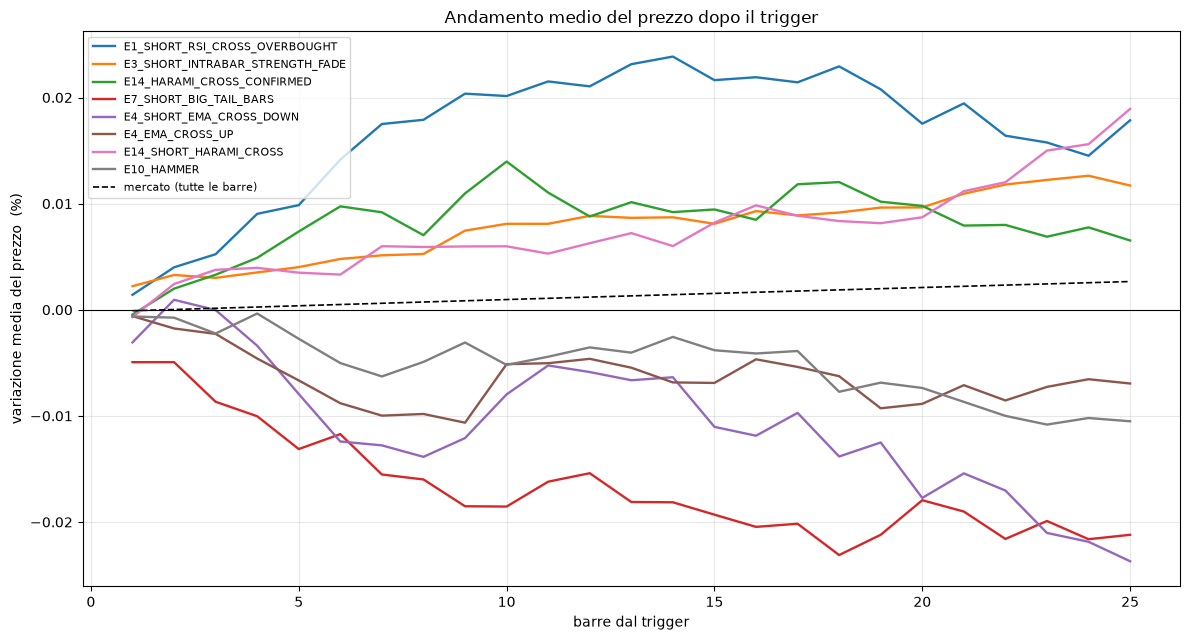

In [ ]:
entry_candidate = [n for n in eng.registry.list_entries()]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()

#### LONG side

In [ ]:
l1 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
l1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
2,E14_HARAMI_CROSS_CONFIRMED,1.942535,0.013966,2.131035,False
24,E9_CLOSING_PATTERN_ONLY_II,1.212031,0.008706,0.989145,False
18,E3_LONG_INTRABAR_WEAKNESS_FADE,0.988750,0.007119,1.255894,False
21,E13_HARAMI_CONFIRMED,0.950130,0.006830,1.135959,False
19,E14_HARAMI_CROSS,0.943938,0.006797,1.240901,False
30,E13_HARAMI,0.338169,0.002434,0.820258,False


In [ ]:
l2 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)
l2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
4,E4_SHORT_EMA_CROSS_DOWN,-3.293442,-0.023697,-2.005144,False
3,E7_SHORT_BIG_TAIL_BARS,-3.205237,-0.023111,-2.035564,False
23,E6_SHORT_BACK_IN_STYLE,-3.077882,-0.022098,-1.109933,False
8,E5_SHORT_QUICK_PULLBACK,-2.248720,-0.016185,-1.730354,False
10,E9_SHORT_CLOSING_PATTERN_ONLY_II,-1.178072,-0.008483,-1.652286,False
32,E18_SHORT_THREE_OUTSIDE,-1.081526,-0.007806,-0.806482,False


#### SHORT side

In [ ]:
s1 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
s1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
0,E1_SHORT_RSI_CROSS_OVERBOUGHT,3.323878,0.023859,3.302665,False
11,E14_SHORT_HARAMI_CROSS_CONFIRMED,3.191537,0.022940,1.571951,False
6,E14_SHORT_HARAMI_CROSS,2.633172,0.018930,1.851276,False
1,E3_SHORT_INTRABAR_STRENGTH_FADE,1.756888,0.012630,2.289920,False
17,E13_SHORT_HARAMI,0.952343,0.006850,1.295731,False
35,E13_SHORT_HARAMI_CONFIRMED,0.635580,0.004575,0.691328,False


In [ ]:
s2 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)

s2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
12,E18_THREE_OUTSIDE,-1.824184,-0.013101,-1.546152,False
25,E1_RSI_CROSS_OVERSOLD,-1.818012,-0.013102,-0.970242,False
7,E10_HAMMER,-1.503353,-0.010818,-1.832247,False
5,E4_EMA_CROSS_UP,-1.479004,-0.010640,-1.974799,False
14,E8_CLOSING_PATTERN_ONLY,-1.167458,-0.008391,-1.459472,False
34,E7_BIG_TAIL_BARS,-1.124781,-0.008099,-0.757086,False


### LONG Dataframe

In [ ]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_long_selected_feat  = l1.iloc[:2,0].to_list() + s1.iloc[:2,0].to_list()

df_LONG = df[colonne_ohlcv + entry_long_selected_feat + colonne_eventi]
df_LONG

,Open,High,Low,Close,Volume,E14_HARAMI_CROSS_CONFIRMED,E9_CLOSING_PATTERN_ONLY_II,E4_SHORT_EMA_CROSS_DOWN,E7_SHORT_BIG_TAIL_BARS,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-03 00:00:00,1.43912,1.44037,1.43878,1.44019,481,False,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
2025-01-03 00:15:00,1.44015,1.44036,1.43954,1.43992,500,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 00:30:00,1.43992,1.44062,1.43992,1.44045,584,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 00:45:00,1.44054,1.44060,1.44038,1.44038,658,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 01:00:00,1.44038,1.44075,1.44003,1.44068,115,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-25 22:30:00,1.41438,1.41454,1.41435,1.41453,441,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,False
2026-09-25 22:45:00,1.41453,1.41470,1.41426,1.41446,461,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,False
2026-09-25 23:00:00,1.41446,1.41457,1.41433,1.41443,362,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,False


#### SHORT Dataframe

In [ ]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_short_selected_feat = l2.iloc[:2,0].to_list() + s2.iloc[:2,0].to_list()

df_SHORT = df[colonne_ohlcv + entry_short_selected_feat + colonne_eventi]
df_SHORT

,Open,High,Low,Close,Volume,E1_SHORT_RSI_CROSS_OVERBOUGHT,E14_SHORT_HARAMI_CROSS_CONFIRMED,E18_THREE_OUTSIDE,E1_RSI_CROSS_OVERSOLD,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-03 00:00:00,1.43912,1.44037,1.43878,1.44019,481,False,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
2025-01-03 00:15:00,1.44015,1.44036,1.43954,1.43992,500,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 00:30:00,1.43992,1.44062,1.43992,1.44045,584,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 00:45:00,1.44054,1.44060,1.44038,1.44038,658,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
2025-01-03 01:00:00,1.44038,1.44075,1.44003,1.44068,115,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-25 22:30:00,1.41438,1.41454,1.41435,1.41453,441,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,False
2026-09-25 22:45:00,1.41453,1.41470,1.41426,1.41446,461,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,False
2026-09-25 23:00:00,1.41446,1.41457,1.41433,1.41443,362,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,False
